In [1]:
# Step 1: Install Required Libraries (if not already installed)
!pip install torchvision

# Step 2: Import Libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models
import matplotlib.pyplot as plt
import numpy as np
import os


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the dataset path
data_dir = '/content/drive/MyDrive/mushroom_data'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

# List contents of MyDrive
print("MyDrive:", os.listdir('/content/drive/MyDrive'))

# List contents of mushroom_data
mushroom_path = '/content/drive/MyDrive/mushroom_data'
print("mushroom_data:", os.listdir(mushroom_path))


Mounted at /content/drive
🔍 MyDrive: ['4kv0a8J.png', 'I AM UNDERNEATH.docx', 'Desktop.7z', 'Project proposal (2 pages + title).gdoc', 'Narrative & You.docx', 'Project Vidovdan', 'Colab Notebooks', 'TransferLearning2025.ipynb', '2025-05-14 11-35-11.mp4', 'mushroom_data']
📂 mushroom_data: ['edible', 'poisonous']


In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# Define transforms for training and testing
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize to what ResNet expects
    transforms.ToTensor(),           # Convert images to PyTorch tensors
    transforms.Normalize(            # Normalize to ImageNet standards
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load the dataset
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Optional: view class names
print("Detected classes:", dataset.classes)


Detected classes: ['edible', 'poisonous']


In [12]:
from torch.utils.data import random_split

# Define the split ratio (e.g., 80% training, 20% validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

📦 Training samples: 5411
📦 Validation samples: 1353


In [13]:
import torch
import torch.nn as nn
from torchvision import models

# Automatically detect if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze all layers so we only train the final layer
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_classes = len(dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to device (GPU or CPU)
model = model.to(device)

💻 Using device: cpu


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 83.6MB/s]


In [17]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Training loop
num_epochs = 5  # You can increase later
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {train_acc:.2f}%")


Epoch 1/5, Loss: 0.5877, Accuracy: 68.60%
Epoch 2/5, Loss: 0.5932, Accuracy: 68.80%
Epoch 3/5, Loss: 0.6039, Accuracy: 67.38%
Epoch 4/5, Loss: 0.5866, Accuracy: 69.10%
Epoch 5/5, Loss: 0.5798, Accuracy: 68.82%


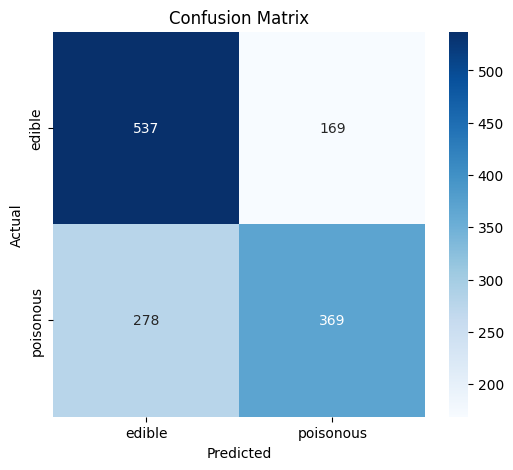

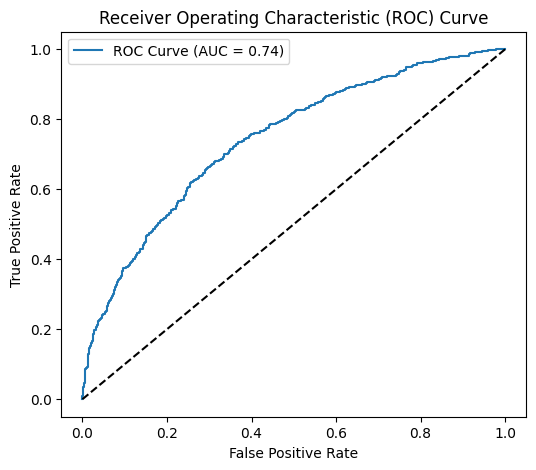

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn.functional as F

# Ensure model is in evaluation mode
model.eval()

# Containers for true labels and predictions
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # for ROC (assuming class 1 = poisonous)

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()



In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_squared_error, average_precision_score
)
import numpy as np

# Ensure these are NumPy arrays
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Binary classification assumes class 1 is 'poisonous'
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
mse = mean_squared_error(all_labels, all_preds)
rmse = np.sqrt(mse)
roc_auc = roc_auc_score(all_labels, all_probs)
pr_auc = average_precision_score(all_labels, all_probs)  # Precision-Recall AUC

# Print results
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall (Sensitivity): {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")
print(f"ROC AUC Score: {roc_auc:.3f}")
print(f"Mean Squared Error: {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")
print(f"Precision-Recall AUC Score: {pr_auc:.3f}")


Accuracy: 66.96%
Precision: 68.59%
Recall (Sensitivity): 57.03%
F1 Score: 62.28%
ROC AUC Score: 0.742
Mean Squared Error: 0.330
Root Mean Squared Error: 0.575
Precision-Recall AUC Score: 0.724
